<a href="https://colab.research.google.com/github/GarzonDiegoFEUP/chalcogenide-perovskite-screening/blob/python311-migration/notebooks/2_1_StructureRelaxation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Why Run This Notebook in Google Colab?

This notebook uses the Meta **Universal Models for Atoms (UMA)
 MLIP** model for structure relaxation, which requires GPU acceleration for efficient computation. Google Colab provides free GPU access (typically NVIDIA Tesla T4 or better), making it the ideal environment for running this computationally intensive task.

The UMA model is a universal materials IP that can predict material properties and forces across diverse chemical spaces. For more details about the model architecture and capabilities, see:
- **Paper**: [UMA: A Family of Universal Models for Atoms](https://arxiv.org/abs/2506.23971) (arXiv preprint)
- **FairChem Documentation**: [FairChem Open Catalyst Project](https://github.com/FAIR-Chem/fairchem)

Running this locally without a GPU would be significantly slower and may exceed memory constraints.

# Install packages and clone repo

In [1]:
!pip install -U huggingface_hub
!pip install fairchem-core

import os
import sys

# If you cloned the repo into /content/chalcogenide-perovskite-screening
repo_path = '/content/chalcogenide-perovskite-screening' 

if not os.path.exists(repo_path):
    !git clone -b python311-migration https://github.com/GarzonDiegoFEUP/chalcogenide-perovskite-screening.git

sys.path.append(repo_path)
os.chdir(repo_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 119.9 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.0
    Uninstalling hf-xet-1.4.0:
      Successfully uninstalled hf-xet-1.4.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
HF_API_KEY="your_huggingface_api_key_here"  # Replace with your actual Hugging Face API key

from huggingface_hub import login

login(token=HF_API_KEY)
os.environ["HF_TOKEN"] = HF_API_KEY

# Structure relaxation

In [3]:
import ase.io
import os
from ase.optimize import FIRE
from ase.filters import FrechetCellFilter
from fairchem.core import pretrained_mlip, FAIRChemCalculator

# 1. Setup the UMA model (moved outside function for efficiency)
print("Loading model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1p2", device="cuda")
calc = FAIRChemCalculator(predictor, task_name="omat")
print("Model loaded successfully!")

def relax_cif_structure(cif_filepath):
    """
    Relaxes a chalcogenide perovskite structure from a CIF file.

    Args:
        cif_filepath (str): Path to the input CIF file.

    Returns:
        tuple: (formula, initial_energy, relaxed_energy, initial_energy_per_atom, relaxed_energy_per_atom)
    """

    # 2. Load your chalcogenide perovskite from a CIF file
    atoms = ase.io.read(cif_filepath)
    atoms.calc = calc # Use the globally defined calculator

    formula = atoms.get_chemical_formula()
    initial_energy = atoms.get_potential_energy()
    num_atoms = atoms.get_global_number_of_atoms()
    initial_energy_per_atom = initial_energy / num_atoms
    print(f"Processing {cif_filepath} - Initial Energy: {initial_energy:.4f} eV, Initial Energy per Atom: {initial_energy_per_atom:.4f} eV/atom")

    # 3. Setup the relaxation filter
    # FrechetCellFilter allows both atom positions and cell tensors to relax
    filtered_atoms = FrechetCellFilter(atoms)

    # 4. Run the optimizer
    # 0.05 is the force convergence (eV/A), 100 is the max steps
    opt = FIRE(filtered_atoms)
    opt.run(fmax=0.05, steps=100)

    # 5. Save the relaxed chalcogenide perovskite
    base_name = os.path.basename(cif_filepath)
    output_dir = "data/crystaLLM/relaxed_cif_files"
    os.makedirs(output_dir, exist_ok=True)
    output_filename = f"{output_dir}/{base_name}"
    ase.io.write(output_filename, atoms)

    relaxed_energy = atoms.get_potential_energy()
    relaxed_energy_per_atom = relaxed_energy / num_atoms
    print(f"Final Energy for {base_name}: {relaxed_energy:.4f} eV, Final Energy per Atom: {relaxed_energy_per_atom:.4f} eV/atom")
    print(f"Structure saved to {output_filename}")

    return formula, initial_energy, relaxed_energy, initial_energy_per_atom, relaxed_energy_per_atom

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


checkpoints/uma-s-1p2.pt:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

iso_atom_elem_refs.yaml: 0.00B [00:00, ?B/s]

form_elem_refs.yaml: 0.00B [00:00, ?B/s]

Model loaded successfully!


In [4]:
import pandas as pd
import glob

cif_directory = "data/crystaLLM/cif_files"
cif_files = glob.glob(os.path.join(cif_directory, "*.cif"))

results = []

print("\n--- Starting batch relaxation for all CIF files ---")
for cif_filepath in cif_files:
    try:
        file_name = os.path.basename(cif_filepath)
        formula, initial_e, relaxed_e, initial_e_pa, relaxed_e_pa = relax_cif_structure(cif_filepath)
        results.append({
            "File Name": file_name,
            "Compound": formula,
            "Initial Energy (eV)": initial_e,
            "Relaxed Energy (eV)": relaxed_e,
            "Initial Energy/Atom (eV/atom)": initial_e_pa,
            "Relaxed Energy/Atom (eV/atom)": relaxed_e_pa
        })
    except Exception as e:
        print(f"Error processing {cif_filepath}: {e}")

# Create DataFrame
df_results = pd.DataFrame(results)

print("\n--- Relaxation Summary --- ")
print(df_results.head())



--- Starting batch relaxation for all CIF files ---
Processing data/crystaLLM/cif_files/UInSe3_1.cif - Initial Energy: -110.5675 eV, Initial Energy per Atom: -5.5284 eV/atom
      Step     Time          Energy          fmax
FIRE:    0 13:40:05     -110.567512        0.779929
FIRE:    1 13:40:05     -110.610137        0.755559
FIRE:    2 13:40:06     -110.687027        0.709672
FIRE:    3 13:40:06     -110.784017        0.647001
FIRE:    4 13:40:06     -110.885181        0.573109
FIRE:    5 13:40:06     -110.976754        0.494074
FIRE:    6 13:40:06     -111.049762        0.416096
FIRE:    7 13:40:06     -111.101152        0.343459
FIRE:    8 13:40:06     -111.134733        0.271348
FIRE:    9 13:40:07     -111.148611        0.200928
FIRE:   10 13:40:07     -111.149617        0.200784
FIRE:   11 13:40:07     -111.151613        0.200513
FIRE:   12 13:40:07     -111.154480        0.200113
FIRE:   13 13:40:07     -111.158073        0.199635
FIRE:   14 13:40:07     -111.162268        0.19

In [5]:
df_results['Energy Reduction/Atom (eV/atom)'] = df_results['Initial Energy/Atom (eV/atom)'] - df_results['Relaxed Energy/Atom (eV/atom)']
df_results.head()

,File Name,Compound,Initial Energy (eV),Relaxed Energy (eV),Initial Energy/Atom (eV/atom),Relaxed Energy/Atom (eV/atom),Energy Reduction/Atom (eV/atom)
0,UInSe3_1.cif,In4Se12U4,-110.567512,-111.355351,-5.528376,-5.567768,0.039392
1,EuScS3_1.cif,Eu4S12Sc4,-151.041616,-151.553805,-7.552081,-7.577690,0.025609
2,YbEuS3_1.cif,Eu4S12Yb4,-131.165668,-145.598019,-6.558283,-7.279901,0.721618
3,SmLuS3_1.cif,Lu4S12Sm4,-127.114690,-127.180993,-6.355734,-6.359050,0.003315
4,ScUS3_1.cif,S12Sc4U4,-150.908009,-151.554292,-7.545400,-7.577715,0.032314


In [28]:
import re

def normalize_formula(formula):
    elements = re.findall(r'([A-Z][a-z]?\d*)', formula)
    parsed = []
    for el in elements:
        match = re.match(r'([A-Z][a-z]?)(\d*)', el)
        elem = match.group(1)
        coeff = int(match.group(2)) if match.group(2) else 1
        coeff //= 4  # integer division
        parsed.append((elem, coeff))
    
    # Find X: S or Se
    x_elem = None
    cations = []
    for elem, coeff in parsed:
        if elem in ['S', 'Se']:
            x_elem = elem
        else:
            cations.append((elem, coeff))
    
    if x_elem is None:
        raise ValueError(f"No S or Se found in {formula}")
    
    # Assume first two cations are A and B
    if len(cations) != 2:
        raise ValueError(f"Expected 2 cations, got {len(cations)} in {formula}")
    
    a, b = cations[0][0], cations[1][0]
    return f"{a}{b}{x_elem}3"

# Apply to the column
df_results['Compound'] = df_results['Compound'].apply(normalize_formula)

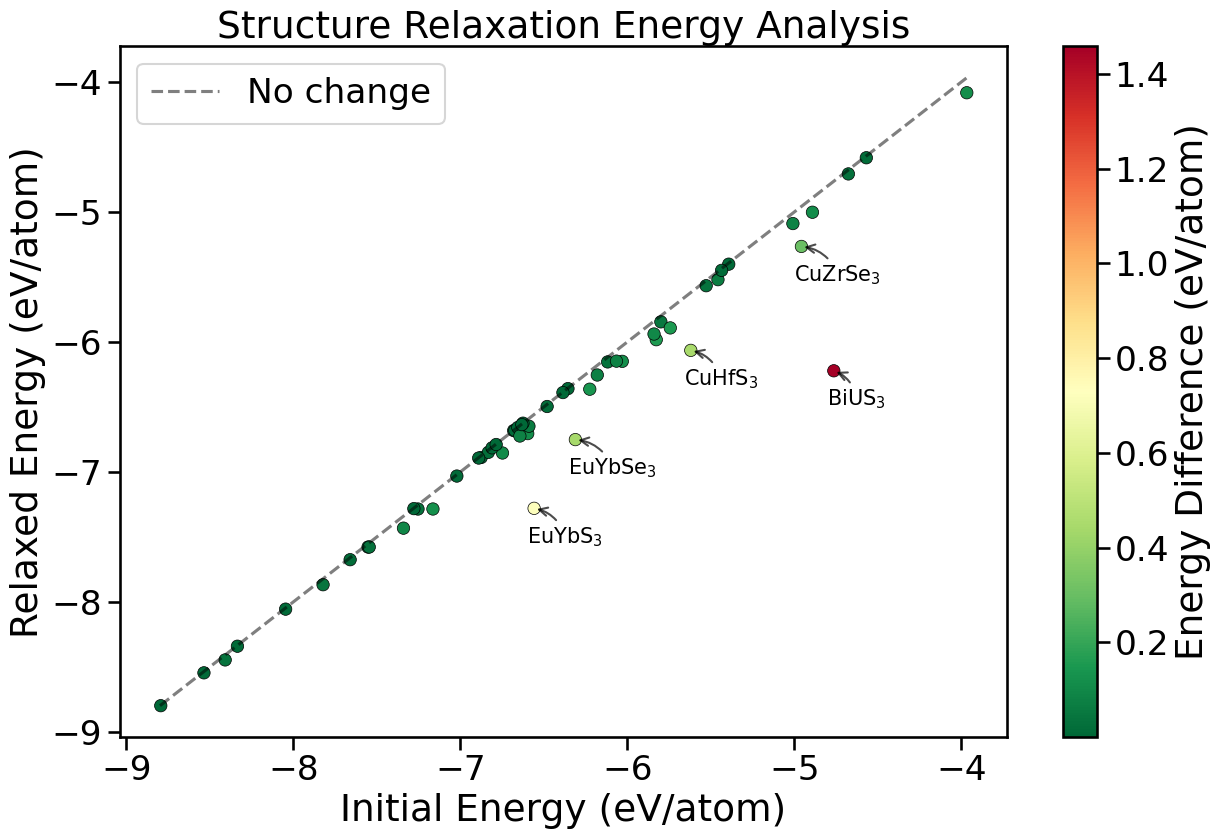

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style for paper-ready plots
sns.set_context('talk', font_scale=1.5)

# Calculate absolute energy reduction for labeling
df_results['Abs Energy Reduction'] = df_results['Energy Reduction/Atom (eV/atom)'].abs()

# Identify compounds with high absolute energy reduction (top 5)
top_compounds = df_results.nlargest(5, 'Abs Energy Reduction')

plt.figure(figsize=(13, 9))

# Create scatter plot with colorbar
sc = plt.scatter(
    df_results['Initial Energy/Atom (eV/atom)'],
    df_results['Relaxed Energy/Atom (eV/atom)'],
    c=df_results['Energy Reduction/Atom (eV/atom)'],
    cmap='RdYlGn_r',  # Green for stable (low reduction), Red for unstable (high reduction)
    s=80,
    #alpha=0.8,
    edgecolors='black',
    linewidth=0.5
)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Energy Difference (eV/atom)')#, fontsize=14, labelpad=10)
#cbar.ax.tick_params(labelsize=12)

# Add diagonal reference line
min_val = min(df_results['Initial Energy/Atom (eV/atom)'].min(), df_results['Relaxed Energy/Atom (eV/atom)'].min())
max_val = max(df_results['Initial Energy/Atom (eV/atom)'].max(), df_results['Relaxed Energy/Atom (eV/atom)'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No change')

# Label compounds with high absolute energy reduction
for idx, row in top_compounds.iterrows():
    plt.annotate(
        row['Compound'].replace("3", "$_3$"),
        (row['Initial Energy/Atom (eV/atom)'], row['Relaxed Energy/Atom (eV/atom)']),
        xytext=(-5, -25),
        textcoords='offset points',
        fontsize=15,
        #bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='black', alpha=0.7)
    )

plt.title('Structure Relaxation Energy Analysis')#, fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Initial Energy (eV/atom)')#, fontsize=14)
plt.ylabel('Relaxed Energy (eV/atom)')#, fontsize=14)
plt.legend(loc='upper left')#, fontsize=12)
plt.tight_layout()

plt.savefig('reports/figures/scatter_plot_energy_relaxation.png', dpi=300, bbox_inches='tight')

plt.show()

In [29]:
df_results.to_csv('data/crystaLLM/structure_relaxation_results.csv', index=False)